In [2]:
import sys
print(sys.executable)

d:\projet_ml_retail\venv\Scripts\python.exe


# 1️⃣ Charger les données

In [3]:
import pandas as pd
df = pd.read_csv(r"D:\projet_ml_retail\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv")
df.head()

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


# 2️⃣ Vérifier les dimensions et types

In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  FirstPurchaseDaysAgo       4372 non-null   int64

# 3️⃣ Valeurs manquantes

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]
(df.isnull().mean() * 100).sort_values(ascending=False)

Age                          29.986276
AvgDaysBetweenPurchases       1.806953
Frequency                     0.000000
CustomerID                    0.000000
MonetaryTotal                 0.000000
MonetaryAvg                   0.000000
MonetaryMin                   0.000000
MonetaryStd                   0.000000
TotalQuantity                 0.000000
AvgQuantityPerTransaction     0.000000
MinQuantity                   0.000000
MonetaryMax                   0.000000
MaxQuantity                   0.000000
CustomerTenureDays            0.000000
PreferredDayOfWeek            0.000000
FirstPurchaseDaysAgo          0.000000
PreferredHour                 0.000000
PreferredMonth                0.000000
WeekendPurchaseRatio          0.000000
Recency                       0.000000
UniqueProducts                0.000000
UniqueDescriptions            0.000000
UniqueCountries               0.000000
AvgProductsPerTransaction     0.000000
ZeroPriceCount                0.000000
CancelledTransactions    

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,Churn
count,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,...,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,3061.000000,4372.000000,4372.000000,4372.000000
mean,15299.677722,92.047118,5.075480,1898.459701,28.839013,88.672383,-86.425754,185.179522,1122.344007,22.389288,...,0.009149,2.036825,0.032045,93.053294,5.075480,19.883969,49.149951,21.778591,5.328225,0.332571
std,1722.390705,100.765435,9.338754,8219.345141,127.323926,2689.001161,2876.398935,2881.283699,4672.790720,213.257466,...,0.126218,7.340449,0.107003,232.471608,9.338754,18.512016,18.267835,139.267307,15.410883,0.471188
min,12346.000000,1.000000,1.000000,-4287.630000,-4287.630000,0.000000,-168469.600000,-4287.630000,-303.000000,-144.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,18.000000,-1.000000,-1.000000,0.000000
25%,13812.750000,17.000000,1.000000,293.362500,10.985960,6.226414,-11.500000,31.800000,153.000000,5.475745,...,0.000000,0.000000,0.000000,17.000000,1.000000,8.000000,34.000000,1.000000,2.000000,0.000000
50%,15300.500000,50.000000,3.000000,648.075000,16.918616,10.349780,0.790000,52.020000,365.000000,9.494392,...,0.000000,0.000000,0.000000,42.000000,3.000000,14.600000,49.000000,2.000000,3.000000,0.000000
75%,16778.250000,143.000000,5.000000,1611.725000,23.542941,20.629858,6.960000,102.000000,962.250000,14.008333,...,0.000000,1.000000,0.021009,102.000000,5.000000,25.212500,65.000000,3.000000,4.000000,1.000000
max,18287.000000,374.000000,248.000000,279489.020000,3861.000000,137554.852393,3861.000000,168469.600000,196719.000000,12540.000000,...,4.000000,226.000000,1.000000,7983.000000,248.000000,219.000000,80.000000,999.000000,99.000000,1.000000


In [10]:
import pandas as pd

df = pd.read_csv(r"D:\projet_ml_retail\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv")

# Afficher le type de chaque colonne
print(df.dtypes)

CustomerID                     int64
Recency                        int64
Frequency                      int64
MonetaryTotal                float64
MonetaryAvg                  float64
MonetaryStd                  float64
MonetaryMin                  float64
MonetaryMax                  float64
TotalQuantity                  int64
AvgQuantityPerTransaction    float64
MinQuantity                    int64
MaxQuantity                    int64
CustomerTenureDays             int64
FirstPurchaseDaysAgo           int64
PreferredDayOfWeek             int64
PreferredHour                  int64
PreferredMonth                 int64
WeekendPurchaseRatio         float64
AvgDaysBetweenPurchases      float64
UniqueProducts                 int64
UniqueDescriptions             int64
AvgProductsPerTransaction    float64
UniqueCountries                int64
NegativeQuantityCount          int64
ZeroPriceCount                 int64
CancelledTransactions          int64
ReturnRatio                  float64
T

In [ ]:
df.groupby("Churn")["Age"].mean()

Churn
0    49.410697
1    48.630499
Name: Age, dtype: float64

# Categorical variables

C:\Users\MSI\AppData\Local\Temp\ipykernel_28956\1928897108.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


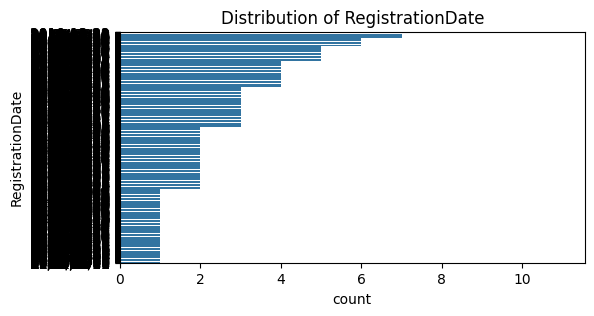

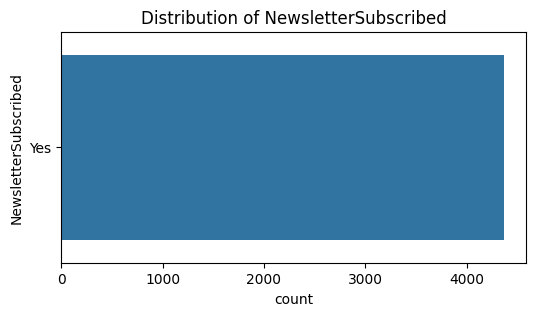

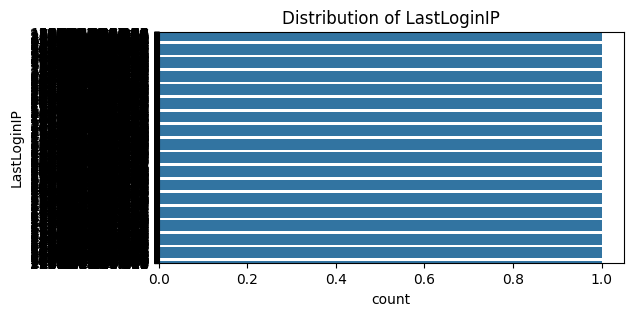

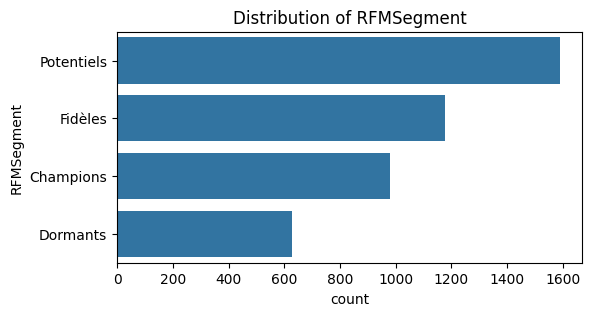

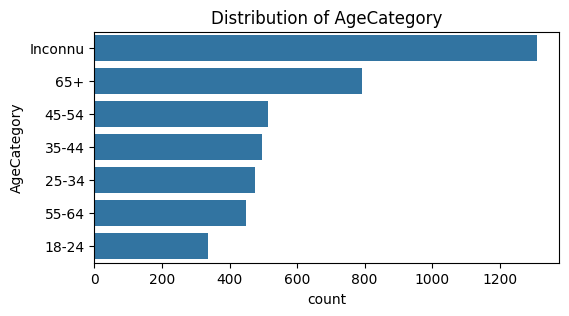

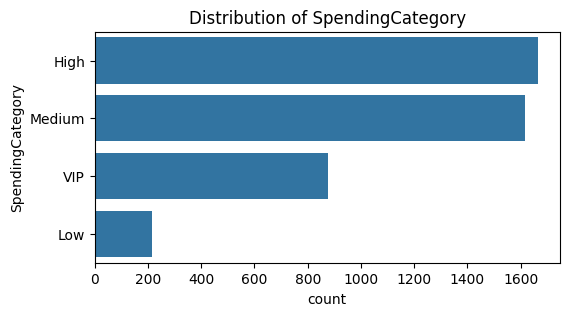

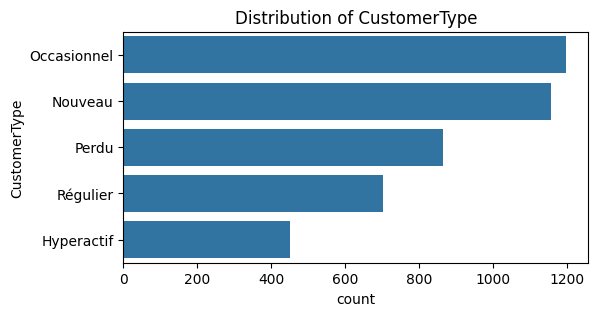

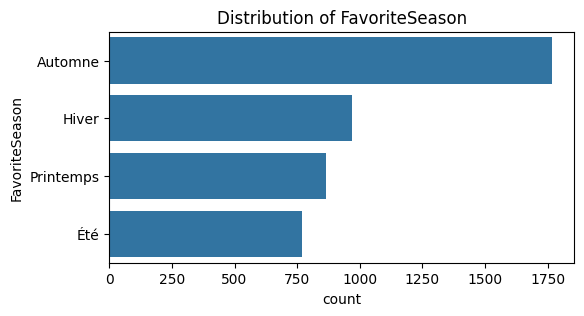

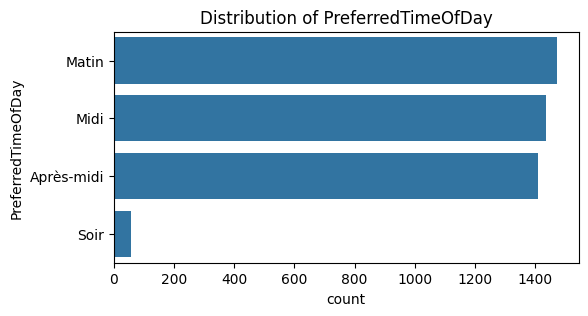

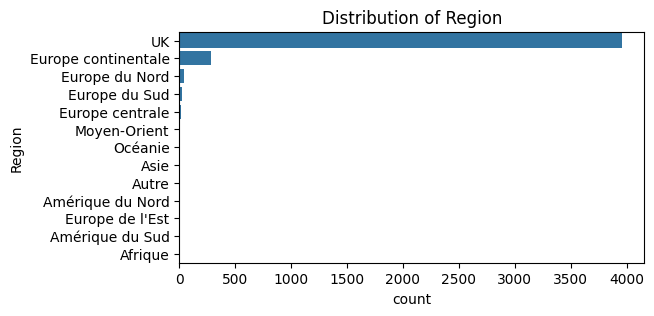

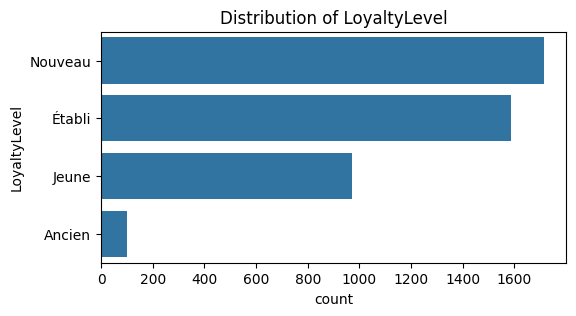

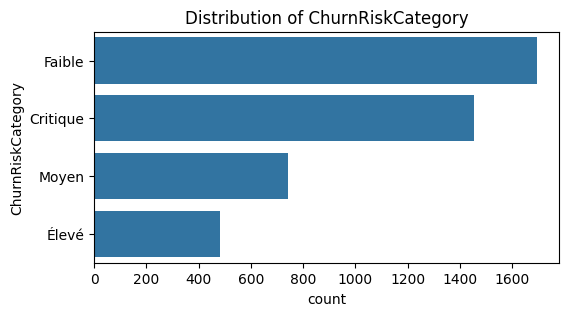

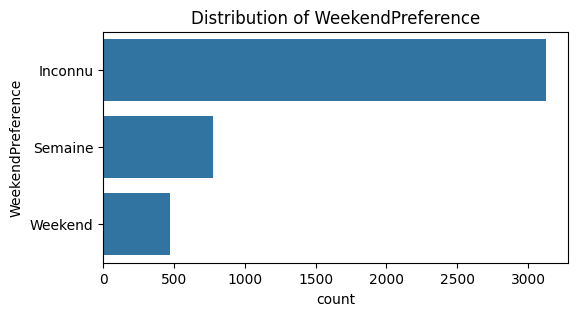

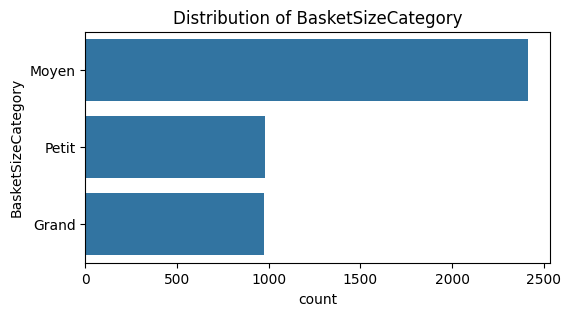

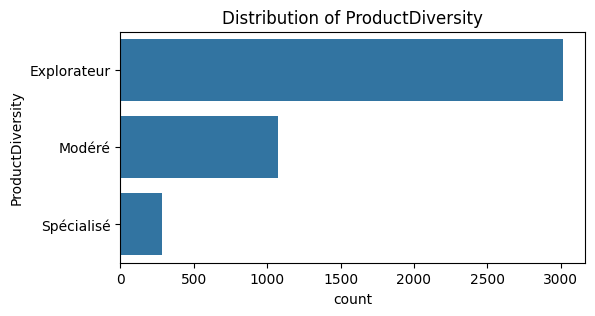

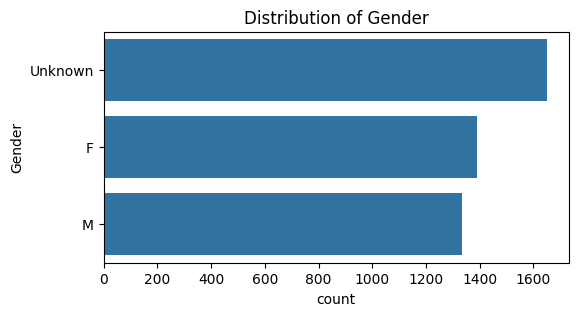

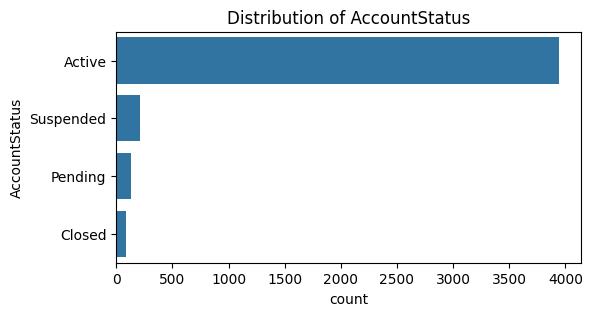

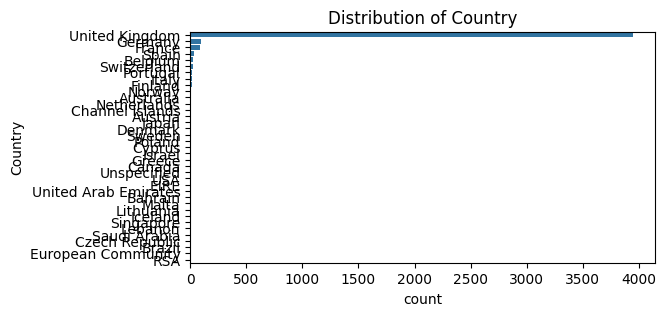

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
# Lister toutes les colonnes
print(df.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg',
       'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity',
       'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity',
       'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek',
       'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio',
       'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions',
       'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount',
       'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio',
       'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age',
       'RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP',
       'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory',
       'SpendingCategory', 'CustomerType', 'FavoriteSeason',
       'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory',
       'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 

# 4️⃣ Outliers

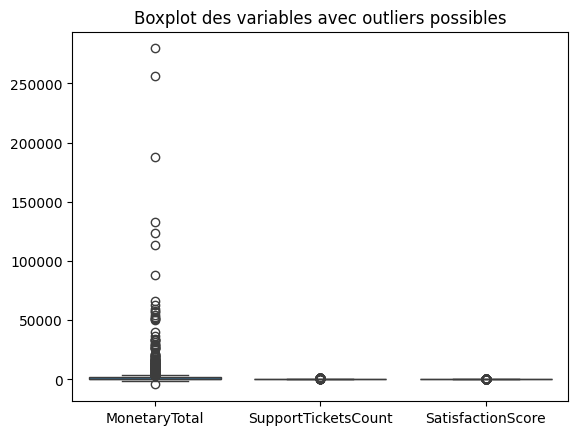

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot des variables avec outliers possibles
sns.boxplot(data=df[['MonetaryTotal', 'SupportTicketsCount', 'SatisfactionScore']])
plt.title("Boxplot des variables avec outliers possibles")
plt.show()

# 5️⃣ Distribution des variables numériques

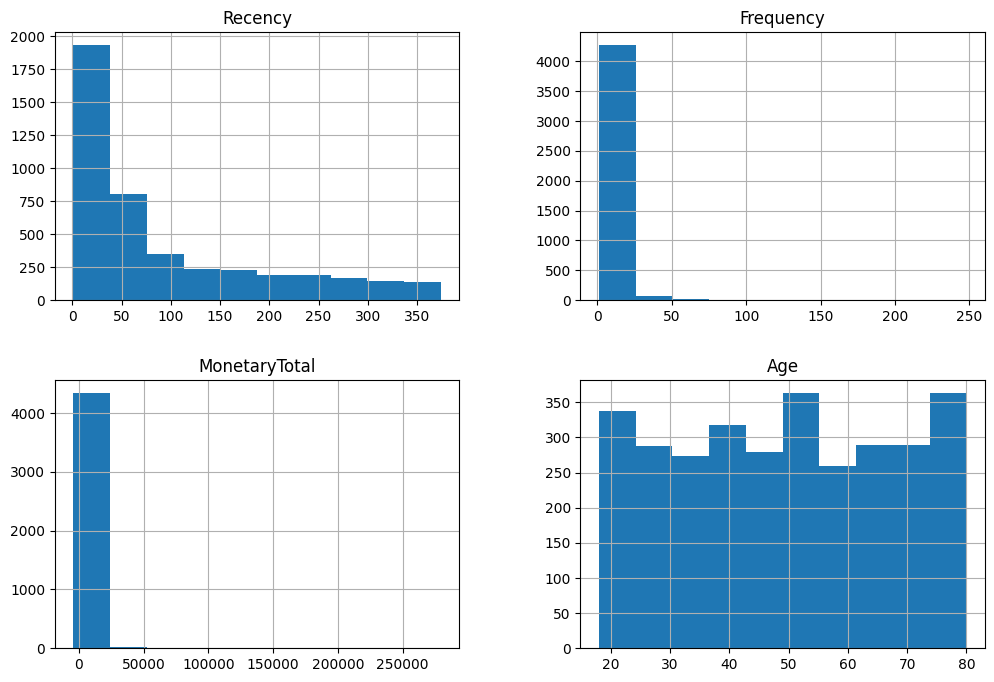

In [ ]:
df[['Recency','Frequency','MonetaryTotal','Age']].hist(figsize=(12,8))
plt.show()

# 6️⃣ Déséquilibre de Churn

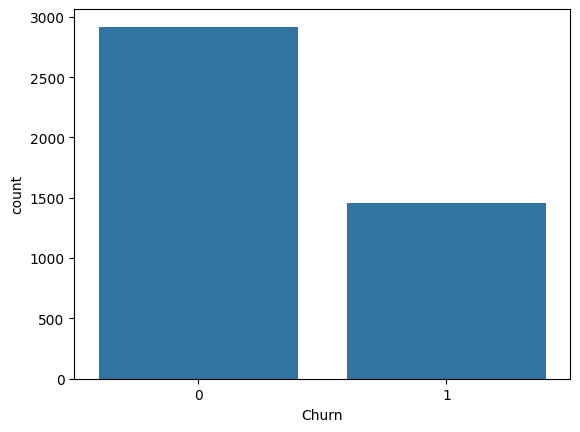

Churn
0    66.742909
1    33.257091
Name: proportion, dtype: float64

In [ ]:
sns.countplot(x='Churn', data=df)
plt.show()
df['Churn'].value_counts(normalize=True) * 100

# 7️⃣ Heatmap de corrélation

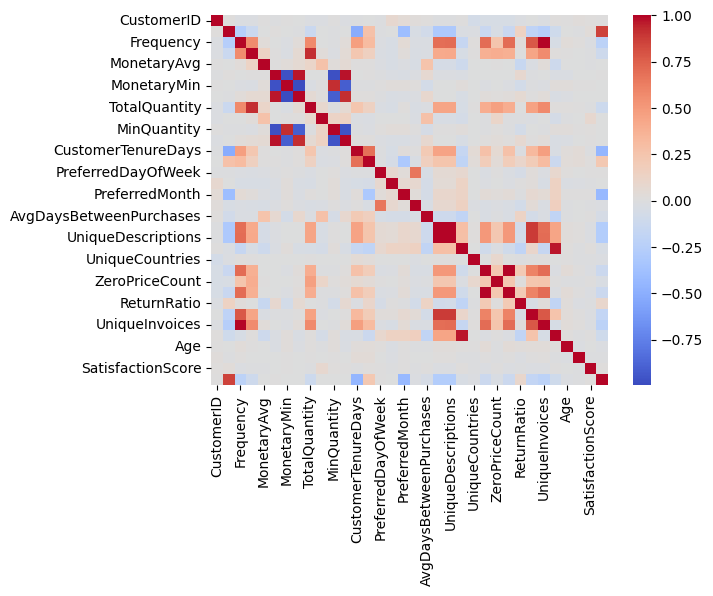

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

# 8️⃣ Multicolinéarité

In [ ]:
import numpy as np
import pandas as pd

# Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_cols.corr()

# Détecter les corrélations fortes
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

# Afficher les corrélations > 0.8
high_corr[abs(high_corr) > 0.8]

NegativeQuantityCount      CancelledTransactions    1.000000
Frequency                  UniqueInvoices           1.000000
UniqueProducts             UniqueDescriptions       0.999930
MonetaryStd                MaxQuantity              0.972585
                           MonetaryMax              0.966135
AvgProductsPerTransaction  AvgLinesPerInvoice       0.963210
MonetaryTotal              TotalQuantity            0.921649
MonetaryMax                MaxQuantity              0.920975
MonetaryMin                MinQuantity              0.919252
UniqueDescriptions         TotalTransactions        0.879734
UniqueProducts             TotalTransactions        0.877638
Recency                    Churn                    0.858951
MonetaryMin                MaxQuantity             -0.915721
MonetaryMax                MinQuantity             -0.915908
MinQuantity                MaxQuantity             -0.961174
MonetaryStd                MonetaryMin             -0.967325
                        

# 9️⃣ Analyse RFM

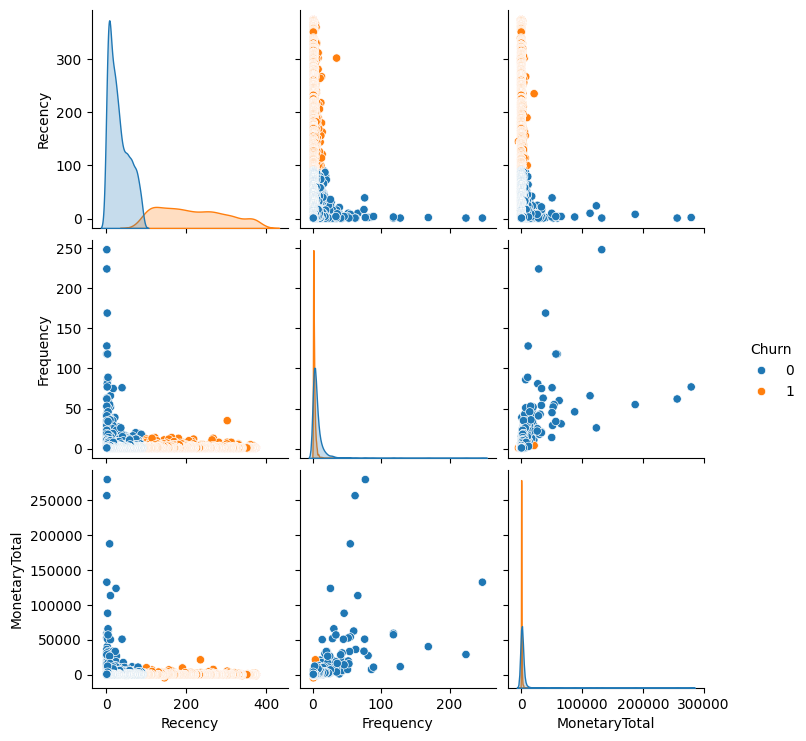

,Recency,Frequency,MonetaryTotal
Churn,,,
0,30.957162,6.542838,2557.666776
1,214.647180,2.130674,575.511803


In [ ]:
sns.pairplot(df[['Recency','Frequency','MonetaryTotal','Churn']], hue='Churn')
plt.show()

df.groupby('Churn')[['Recency','Frequency','MonetaryTotal']].mean()